<div style="text-align: right"><h4>ФБ-61мп Редько-Шпак Родислав</h4></div>
<h1><center><b>Лабораторна робота №1</b></center></h1>
<h3><center>З предмета "Інтелектуальний аналіз даних"</center></h3>
<h4><center>Тема: "Базові алгоритми класифікації у Scikit-learn"</center></h4>
<h5><b><center>Хід роботи:</center></b></h5>

<h2>[0] Загальна інформація</h2>

Метою роботи є ознайомлення з базовим workflow задачі класифікації: від вибору та аналізу даних до навчання, налаштування, порівняння та оцінювання моделей моделей машинного з використанням бібліотеки Scikit-learn.

За завданням потрібно обрати датасет для класифікації, провести його первинний аналіз і попередню обробку, побудувати графіки для дослідження даних, розділити дані на навчальну і тестову вибірки, навчити kNN, Decision Tree, SVM, Random Forest і AdaBoost, підібрати параметри для kNN і SVM, а потім порівняти моделі та обрати найкращу.

Для роботи обрано датасет TUANDROMD (https://archive.ics.uci.edu/dataset/855/tuandromd+%28tezpur+university+android+malware+dataset%29) з UCI Machine Learning Repository. У ньому зібрані дані про Android-застосунки, кожен з яких описаний 241 бінарною ознакою. Перші +-200 ознак показують, чи запитує застосунок певний дозвіл, а решта показують, чи викликає він певні функції Android API (наприклад, надсилання SMS або виконання команд). Цільова змінна "Label" вказує, чи є застосунок шкідливим (malware), чи звичайним (goodware). 

Спочатку було підключено бібліотеки для роботи з даними, побудови графіків і навчання моделей.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 20)
print('всьо ок')

всьо ок


<h2>[I] Завантаження та первинний аналіз даних</h2>

датасет завантажено з csv-файлу:

In [2]:
df = pd.read_csv('TUANDROMD.csv')
print('Розмір датасету:', df.shape)
df.head()

Розмір датасету: (4465, 242)


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware


Датасет має 4465 рядків і 242 колонки, тобто 241 ознаку і мітку класу. Значення ознак записані як 0.0 і 1.0 (хоча мали б бути цілими числами, до речі. тому поправим).


In [3]:
cols = df.columns.tolist()
print('Кількість колонок:', len(cols))
print('\nПерші 10:', cols[:10])
print('\nОстанні 10:', cols[-10:])
print('\nКолонки з дивними назвами:', [c for c in cols if 'goodware' in c])

Кількість колонок: 242

Перші 10: ['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM', 'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION', 'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION', 'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION', 'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE']

Останні 10: ['Landroid/telephony/TelephonyManager;->getLine1Number', 'Landroid/telephony/TelephonyManager;->getNetworkOperator', 'Landroid/telephony/TelephonyManager;->getNetworkOperatorName', 'Landroid/telephony/TelephonyManager;->getNetworkCountryIso', 'Landroid/telephony/TelephonyManager;->getSimOperator', 'Landroid/telephony/TelephonyManager;->getSimOperatorName', 'Landroid/telephony/TelephonyManager;->getSimCountryIso', 'Landroid/telephony/TelephonyManager;->getSimSerialNumber', 'Lorg/apache/http/impl/client/DefaultHttpClient;->execute', 'Label']

Колонки з дивними назвами: ['BIND_goodwareTIFICATION_LISTENER_SERVICE', 'DIAGgoodwareSTIC', 'DOWNLOAD_WITHOUT_goodwareTIFICATION', 'Landroid/location

Спочатку йдуть дозволи, далі виклики API, а остання колонка <i>"Label"</i> є цільовою змінною. Чотири назви колонок виглядають непонятно, наприклад <i>DIAGgoodwareSTIC</i> замість <i>DIAGNOSTIC</i>. Схоже, автори датасету замінили всі "no" на "goodware" і випадково зачепили назви ознак. Ці назви було виправлено, а ознаки розділено на дозволи та виклики API.

In [4]:
df.columns = (df.columns.str.replace('goodwareTIFICATION', 'NOTIFICATION')
                         .str.replace('DIAGgoodwareSTIC', 'DIAGNOSTIC')
                         .str.replace('Kgoodwarewn', 'Known'))

target = 'Label'
features = [c for c in df.columns if c != target]
perm_cols = [c for c in features if '->' not in c]   # дозволи з AndroidManifest
api_cols = [c for c in features if '->' in c]        # виклики API

print('Ознак:', len(features), '| дозволів:', len(perm_cols), '| API-викликів:', len(api_cols))
print('Цільова змінна:', target)

Ознак: 241 | дозволів: 214 | API-викликів: 27
Цільова змінна: Label


ознак 241, з них 214 дозволів і 27 викликів API, як і зазначено в описі датасету.

In [5]:
print(df.dtypes.value_counts(), '\n')
print('Унікальні значення ознак:', np.unique(df[features].dropna().values))
print('Значення цільової змінної:', df[target].unique())

float64    241
str          1
Name: count, dtype: int64 

Унікальні значення ознак: [0. 1.]
Значення цільової змінної: <StringArray>
['malware', nan, 'goodware']
Length: 3, dtype: str


ознаки мають тип float64, а в цільовій змінній, крім malware і goodware, є ще пропуск. Скоріш за все, саме через оці от пропуски ознаки і стали дробовими.

          кількість     %
Label                    
malware        3565  79.8
goodware        899  20.1
NaN               1   0.0


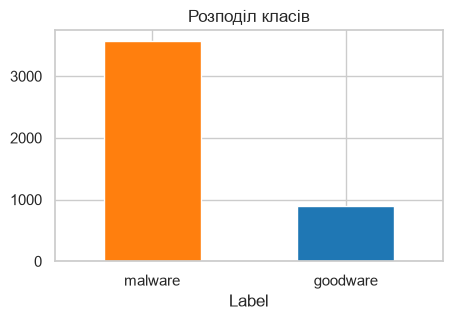

In [6]:
counts = df[target].value_counts(dropna=False)
print(pd.DataFrame({'кількість': counts, '%': (counts / len(df) * 100).round(1)}))

df[target].value_counts().plot.bar(color=['tab:orange', 'tab:blue'], rot=0, figsize=(5, 3))
plt.title('Розподіл класів')
plt.show()

Класи незбалансовані, шкідливих застосунків приблизно 80%, звичайних 20%. Також є один рядок без мітки.

<h2>[II] Попередня обробка даних</h2>

<p align="center"><i><ins>[II.a] Пропущені значення та кодування</ins></i></p>

In [7]:
print('Пропусків усього:', df.isna().sum().sum())
na_rows = df[df.isna().any(axis=1)]
print('Рядків із пропусками:', len(na_rows), '| індекс:', na_rows.index.tolist())
print('Заповнених значень у цьому рядку:', na_rows.notna().sum(axis=1).tolist())

Пропусків усього: 242
Рядків із пропусками: 1 | індекс: [2533]
Заповнених значень у цьому рядку: [0]


Усі 242 пропуски знаходяться в одному рядку (індекс 2533), який повністю порожній. Такий рядок нічого не дає, тому його видаляємо.

Також категоріальних ознак немає, всі ознаки вже мають значення або 0 або 1, тому кодувати їх не потрібно. Закодовано лише цільову змінну: malware -> 1, goodware -> 0. Шкідливий клас взято за 1, бо саме його потрібно знаходити.

In [8]:
df = df.dropna().reset_index(drop=True)
df[features] = df[features].astype(int)
df[target] = df[target].map({'goodware': 0, 'malware': 1})

print('Розмір після видалення:', df.shape)
print(df[target].value_counts())

Розмір після видалення: (4464, 242)
Label
1    3565
0     899
Name: count, dtype: int64


<p align="center"><i><ins>[II.b] Дублікати</ins></i></p>


При перегляді даних було помічено, що прям дуже багато рядків повторюються, тому окремо перевірено кількість дублікатів.

In [9]:
dup = df.duplicated()
print(f'Повних дублікатів: {dup.sum()} з {len(df)} ({dup.mean() * 100:.1f}%)')
print('Унікальних рядків:', (~dup).sum())

print('\nУнікальних профілів у кожному класі:')
print(pd.DataFrame({'усього': df[target].value_counts(), 'унікальних': df.drop_duplicates()[target].value_counts()}))

conflict = df.drop_duplicates().duplicated(subset=features, keep=False).sum()
print('\nРядків з однаковими ознаками, але різними мітками:', conflict)

Повних дублікатів: 3802 з 4464 (85.2%)
Унікальних рядків: 662

Унікальних профілів у кожному класі:
       усього  унікальних
Label                    
0         899         531
1        3565         131

Рядків з однаковими ознаками, але різними мітками: 4


Дублікатів виявилось 85%. Найбільше їх серед шкідливих застосункі, де з 3565 унікальних лише 131. Це можна пояснити тим, що шкідливі програми часто є копіями одна одної з однаковим набором дозволів. Але для навчання це погано, бо при поділі даних більшість тестових рядків буде мати точну копію в навчальній вибірці, і результати загалом вийдуть завищеними (це перевірено в кінці роботи). Тому далі використовуються лише унікальні рядки.

Також є дві пари рядків з однаковими ознаками, але різними мітками. Їх залишено, бо на результат вони майже не впливають.

In [10]:
df_full = df.copy()   # вихідні дані з дублікатами, знадобляться для порівняння в кінці
data = df.drop_duplicates().reset_index(drop=True)

const_cols = [c for c in features if data[c].nunique() == 1]
data = data.drop(columns=const_cols)
features = [c for c in features if c not in const_cols]
perm_cols = [c for c in perm_cols if c in features]
api_cols = [c for c in api_cols if c in features]

print('Видалено константних ознак:', len(const_cols))
print('Підсумковий розмір:', data.shape, '| дозволів:', len(perm_cols), '| API:', len(api_cols))
print(data[target].value_counts().rename({0: 'goodware', 1: 'malware'}))

Видалено константних ознак: 42
Підсумковий розмір: (662, 200) | дозволів: 172 | API: 27
Label
goodware    531
malware     131
Name: count, dtype: int64


Також видалено 42 ознаки, які в усьому датасеті дорівнюють 0, бо ну вони не несуть жодної інфи. Залишилось 662 рядки і 199 ознак.

Після видалення дублікатів співвідношення класів змінилось, тепер шкідливих застосунків лише +- 20%. тому основною метрикою для оцінки моделей буде F1 для класу malware, а не accuracy. Інакше модель, яка завжди відповідає goodware, мала б accuracy 0.8 і виглядала б "непогано".

<h2>[III] Візуалізація та дослідження даних</h2>

Оскільки ознак майже 200, для графіків відібрано 15 ознак, які найсильніше корелюють з цільовою змінною.

In [12]:
def short(c):
    # коротка назва для графіків
    return c.split('->')[-1] + '()' if '->' in c else c

corr_t = data[features].corrwith(data[target]).sort_values(key=abs, ascending=False)
top = corr_t.head(15).index.tolist()
corr_t.head(15).rename(short).round(3).to_frame('corr з Label')

,corr з Label
RECEIVE_BOOT_COMPLETED,0.498
RECEIVE_SMS,0.491
GET_TASKS,0.452
SEND_SMS,0.451
KILL_BACKGROUND_PROCESSES,0.397
openConnection(),-0.367
SYSTEM_ALERT_WINDOW,0.362
READ_PHONE_STATE,0.349
BATTERY_STATS,0.348
DISABLE_KEYGUARD,0.314


Найбільше зі шкідливими застосунками пов'язані дозволи на автозапуск (RECEIVE_BOOT_COMPLETED), роботу з SMS, перегляд і завершення інших процесів. Від'ємну кореляцію мають "openConnection()" і "getLastKnownLocation()", тобто вони частіше трапляються у звичайних застосунках.

<p align="center"><i><ins>[III.a] Heatmap кореляцій</ins></i></p>

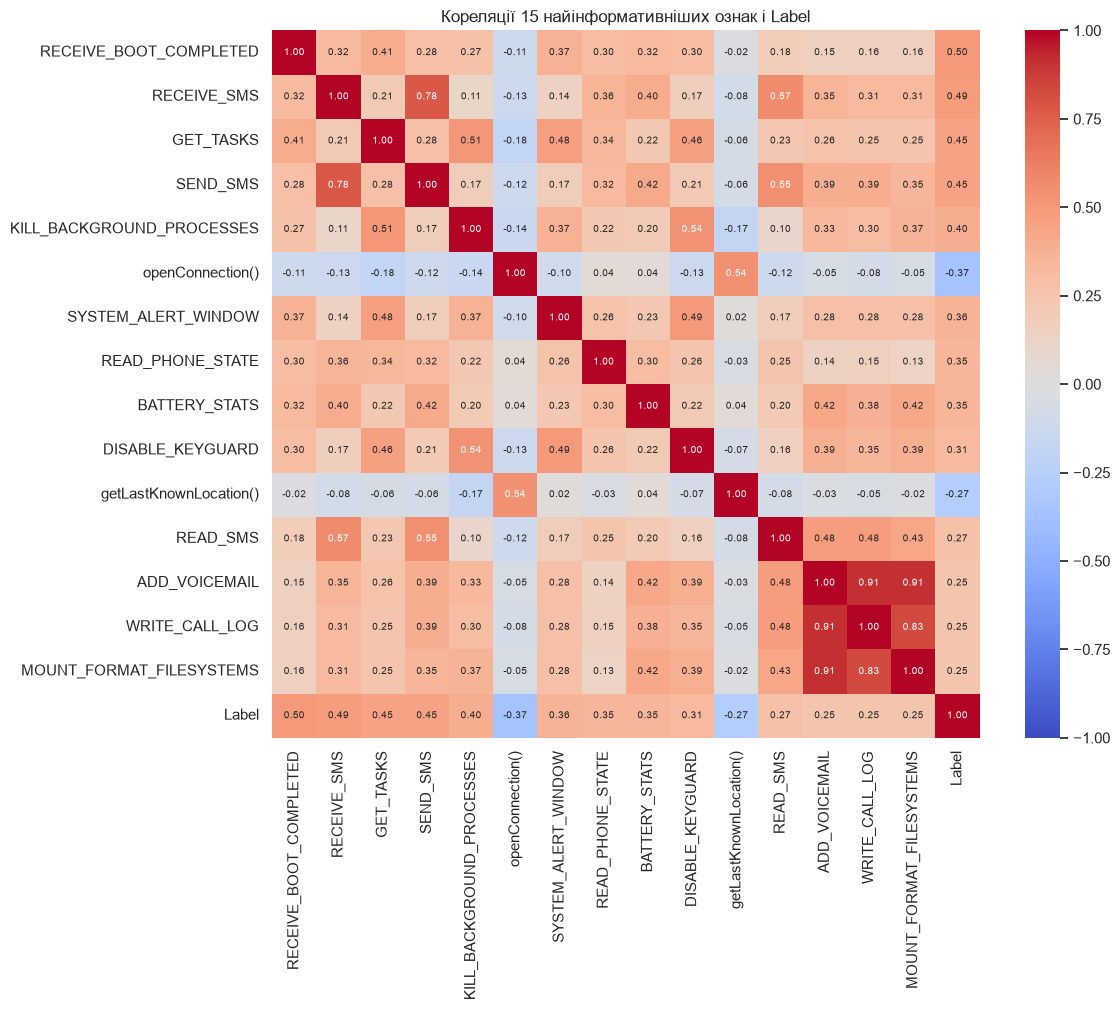

In [13]:
plt.figure(figsize=(12, 10))
corr = data[top + [target]].rename(columns=short).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
plt.title('Кореляції 15 найінформативніших ознак і Label')
plt.tight_layout()
plt.show()

Найбільша кореляція з Label близько 0.5, тому за однією ознакою клас не визначити. Між самими ознаками є кілька сильних зв'язків. RECEIVE_SMS і SEND_SMS корелюють на 0.78, що логічно. ось ADD_VOICEMAIL, WRITE_CALL_LOG і MOUNT_FORMAT_FILESYSTEMS корелює на 0.83-0.91, хоча за змістом ці дозволи ніяк не пов'язані. скоріш за все, їх разом запитують програми з одного сімейства шкідливого ПЗ.

<p align="center"><i><ins>[III.b] Гістограми розподілу ознак</ins></i></p>

Ознаки бінарні, тому звичайна гістограма для кожної з них мало що покаже. Замість цього побудовано гістограми к-сті дозволів (n_perm) і кількості викликів API (n_api) у кожного застосунку.

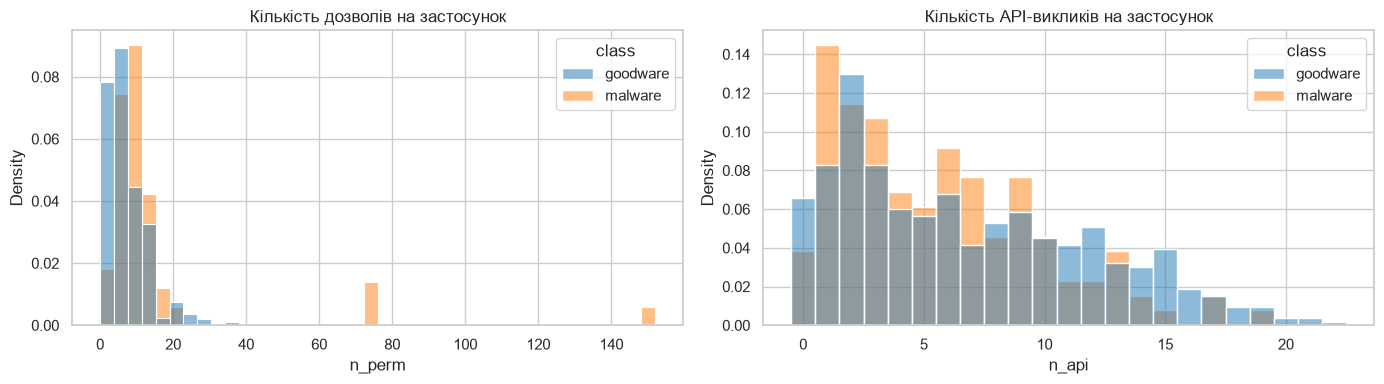

In [14]:
agg = pd.DataFrame({
    'n_perm': data[perm_cols].sum(axis=1),
    'n_api': data[api_cols].sum(axis=1),
    'class': data[target].map({0: 'goodware', 1: 'malware'}),
})
order = ['goodware', 'malware']
pal = {'goodware': 'tab:blue', 'malware': 'tab:orange'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(agg, x='n_perm', hue='class', hue_order=order, palette=pal, bins=40,
             stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Кількість дозволів на застосунок')
sns.histplot(agg, x='n_api', hue='class', hue_order=order, palette=pal, discrete=True,
             stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Кількість API-викликів на застосунок')
plt.tight_layout()
plt.show()

Більшість застосунків запитує десь до 20 дозволів. У шкідливих застосунків дозволів зазвичай більше, а деякі запитують 75 і навіть 150 дозволів. За кількістю викликів API класи майже не відрізняються.

Також для топ-15 ознак показано, яка частка застосунків кожного класу має цю ознаку:

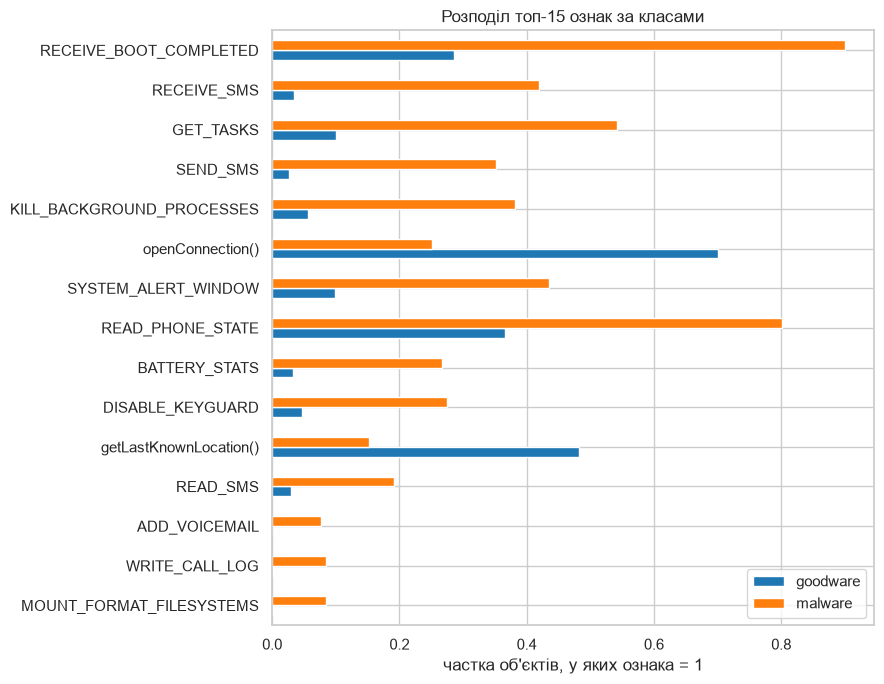

In [15]:
freq = data.groupby(target)[top].mean().T.rename(index=short)
freq.columns = ['goodware', 'malware']

freq.iloc[::-1].plot.barh(figsize=(9, 7), color=['tab:blue', 'tab:orange'])
plt.xlabel("частка об'єктів, у яких ознака = 1")
plt.title('Розподіл топ-15 ознак за класами')
plt.tight_layout()
plt.show()

Отуут різниця між класами помітна прям краще і наочніше. RECEIVE_BOOT_COMPLETED є приблизно у +- 90% шкідливих застосунків і лише у 30% звичайних, READ_PHONE_STATE у 80% проти 37%. Дозволи на SMS у звичайних застосунках майже не трапляються. А от openConnection() навпаки частіше використовують звичайні застосунки (70% проти 25%).

<p align="center"><i><ins>[III.c] Boxplot-и відносно цільової змінної</ins></i></p>

Для бінарних ознак boxplot нічого не показує, тому його побудовано для тих самих n_perm і n_api.

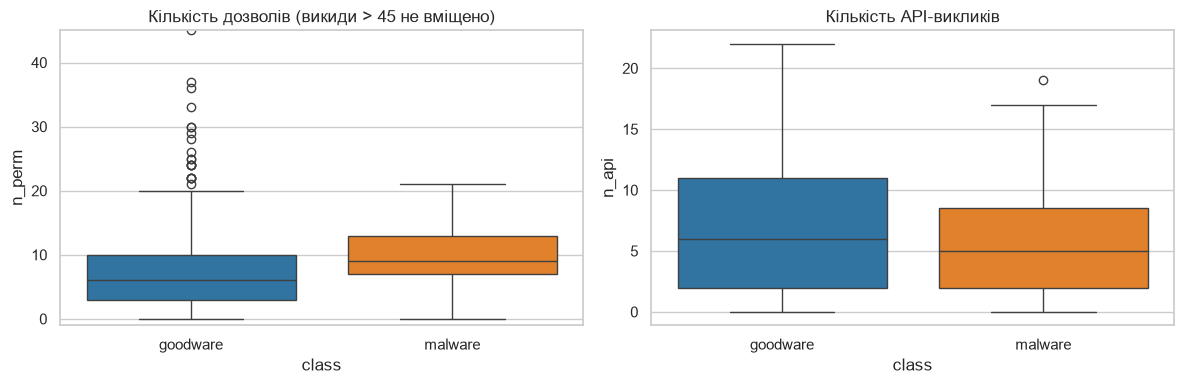

,n_perm,n_api
class,,
goodware,6.0,6.0
malware,9.0,5.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(agg, x='class', y='n_perm', hue='class', order=order, palette=pal, ax=axes[0])
axes[0].set_ylim(-1, 45)
axes[0].set_title('Кількість дозволів (викиди > 45 не вміщено)')
sns.boxplot(agg, x='class', y='n_api', hue='class', order=order, palette=pal, ax=axes[1])
axes[1].set_title('Кількість API-викликів')
plt.tight_layout()
plt.show()

agg.groupby('class')[['n_perm', 'n_api']].median()

У шкідливих застосунків медіана к-сті дозволів більша (9 проти 6), а за викликами API трохи більша у звичайних (6 проти 5). Серед звичайних застосунків більше викидів, тобто програм з 20-45 дозволами. Викиди не видалялись, бо це реальні застосунки, а не помилки в даних, тому ну хай буде.

Загалом видно, що класи відрізняються не якоюсь однією ознакою, а саме набором підозрілих дозволів.

<h2>[IV] Підготовка даних до навчання</h2>

Дані розділено на навчальну і тестову вибірки у співвідношенні 75/25. Через незбалансованість класів використано "stratify=y", щоб частка шкідливих застосунків в обох вибірках була однаковою. Також задано 5-кратну крос-валідацію, яка буде використовуватись далі.

In [17]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Частка malware у train / test:', round(y_train.mean(), 3), '/', round(y_test.mean(), 3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: (496, 199) | Test: (166, 199)
Частка malware у train / test: 0.198 / 0.199


У тестовій вибірці 166 рядків, з них лише 33 мальварь. Це небагато, тому крім результатів на тесті моделі також оцінюються крос-валідацією.

Масштабування потрібне для kNN і SVM, бо вони працюють з відстанями між точками. Для дерева рішень, Random Forest і AdaBoost воно не потрібне. Використано StandardScaler, навчений лише на навчальній вибірці.

In [18]:
scaler = StandardScaler().fit(X_train)
X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=features)

print('Діапазон значень після StandardScaler:',
      round(X_train_sc.values.min(), 2), '...', round(X_train_sc.values.max(), 2))
print('\nОзнаки з найбільшим значенням після масштабування:')
pd.DataFrame({'частка одиниць у train': X_train[features].mean(),
              'max після scaler': X_train_sc.max()}).sort_values('max після scaler').tail(5).round(3)

Діапазон значень після StandardScaler: -2.26 ... 22.25

Ознаки з найбільшим значенням після масштабування:


,частка одиниць у train,max після scaler
BILLING,0.002,22.249
STORAGE,0.002,22.249
SDCARD_WRITE,0.002,22.249
ACCESS_MTK_MMHW,0.002,22.249
MEDIA_BUTTON,0.002,22.249


Видно, що для рідкісних ознак StandardScaler дає значення аж до 22, хоча до цього всі значення були 0 або 1. Через це рідкісні дозволи почнуть сильно впливати на відстані. Тому масштабування для kNN і SVM додано в "Pipeline". також додатково а в пункті [VI] перевірено, чи воно взагалі покращує результат.

<h2>[V] Навчання моделей</h2>

Спочатку всі моделі навчено з параметрами за замовчуванням. Для кожної пораховано метрики на тестовій вибірці (precision, recall і F1 для класу malware) та середній F1 на крос-валідації.

In [19]:
models = {
    'kNN': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM': Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=RANDOM_STATE))]),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
}

def evaluate(model, name):
    pred = model.predict(X_test)
    return {'Модель': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall': recall_score(y_test, pred),
            'F1 (malware)': f1_score(y_test, pred),
            'F1-macro': f1_score(y_test, pred, average='macro')}

rows = []
for name, model in models.items():
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()
    model.fit(X_train, y_train)
    rows.append({**evaluate(model, name), 'CV F1': cv_f1})

baseline = pd.DataFrame(rows).set_index('Модель').round(3)
baseline

,Accuracy,Precision,Recall,F1 (malware),F1-macro,CV F1
Модель,,,,,,
kNN,0.946,0.875,0.848,0.862,0.914,0.838
Decision Tree,0.910,0.737,0.848,0.789,0.866,0.808
SVM,0.964,1.000,0.818,0.900,0.939,0.839
Random Forest,0.946,0.875,0.848,0.862,0.914,0.872
AdaBoost,0.928,0.800,0.848,0.824,0.889,0.846


Отже, accuracy у всіх моделей вище 0.9, але в нашому випадку важливіше дивитись на F1. 
На тесті найкраще виглядає SVM (F1 = 0.90), а на крос-валідації найкращий Random Forest (0.872). Така різниця пояснюється тим, що тестова вибірка мала. Найгірший результат у дерева рішень, воно частіше за інших помилково вважає звичайні застосунки шкідливими:(((

<h2>[VI] Підбір гіперпараметрів</h2>

Параметри підбирались через "GridSearchCV" на навчальній вибірці за метрикою F1. Тестова вибірка тут не використовувалась.

<p align="center"><i><ins>[VI.a] kNN</ins></i></p>

Для kNN перебирались значення "n_neighbors" від 1 до 30, з масштабуванням і без нього.

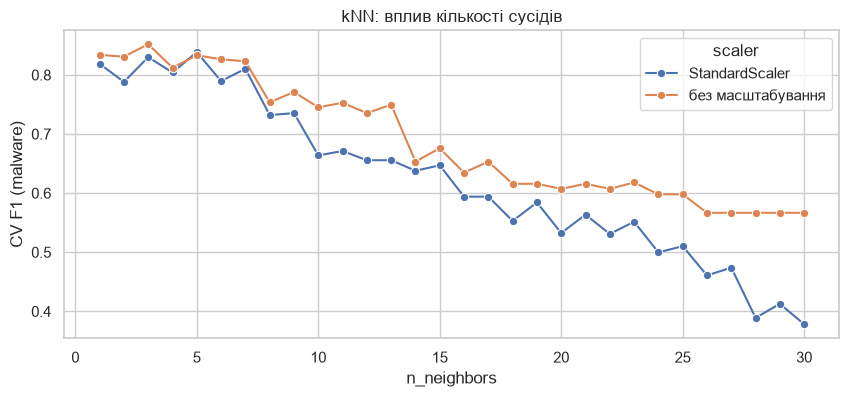

Найкращі параметри: {'model__n_neighbors': 3, 'scaler': 'passthrough'}
CV F1: 0.852


In [22]:
knn_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
    param_grid={'scaler': [StandardScaler(), 'passthrough'],
                'model__n_neighbors': list(range(1, 31))},
    cv=cv, scoring='f1')
knn_grid.fit(X_train, y_train)

res = pd.DataFrame(knn_grid.cv_results_)
res['scaler'] = res['param_scaler'].map(lambda s: 'без масштабування' if s == 'passthrough' else 'StandardScaler')
plt.figure(figsize=(10, 4))
sns.lineplot(res, x='param_model__n_neighbors', y='mean_test_score', hue='scaler', marker='o')
plt.xlabel('n_neighbors'); plt.ylabel('CV F1 (malware)')
plt.title('kNN: вплив кількості сусідів')
plt.show()

print('Найкращі параметри:', knn_grid.best_params_)
print('CV F1:', round(knn_grid.best_score_, 3))

Найкращий результат при k = 3 без масштабування (F1 = 0.852), хоча значення при k = 5 і k = 7 майже такі самі. Зі збільшенням k якість падає, бо шкідливих застосунків мало і серед сусідів переважають звичайні. При парних k результат здебільшого гірший, бо при рівній кількості голосів обирається клас goodware. Без масштабування kNN працює краще майже при всіх k.

<p align="center"><i><ins>[VI.b] SVM</ins></i></p>

Для SVM перебирались значення C (0.1, 1, 10, 100) і gamma (scale, 0.001, 0.01, 0.1, 1), також з масштабуванням і без.

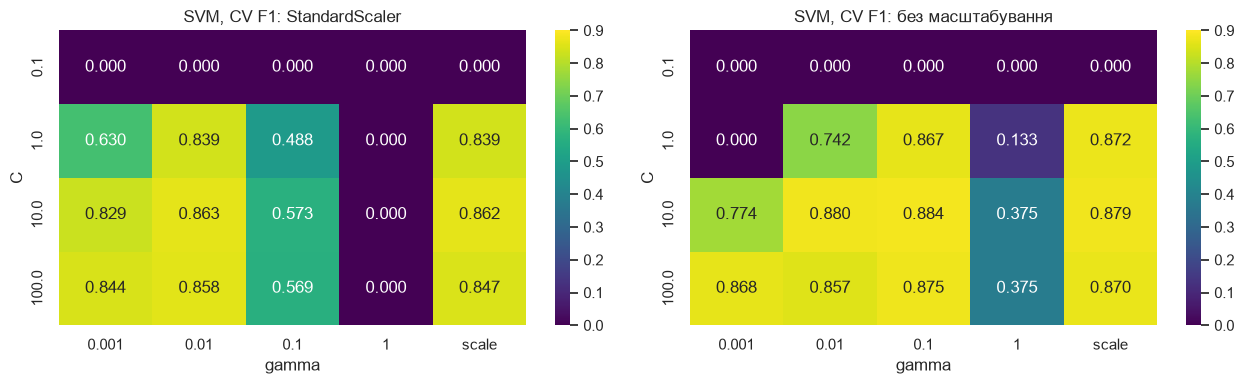

Найкращі параметри: {'model__C': 10, 'model__gamma': 0.1, 'scaler': 'passthrough'}
CV F1: 0.884


In [23]:
svm_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))]),
    param_grid={'scaler': [StandardScaler(), 'passthrough'],
                'model__C': [0.1, 1, 10, 100],
                'model__gamma': ['scale', 0.001, 0.01, 0.1, 1]},
    cv=cv, scoring='f1')
svm_grid.fit(X_train, y_train)

res = pd.DataFrame(svm_grid.cv_results_)
res['gamma'] = res['param_model__gamma'].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sc, title in zip(axes, ['StandardScaler', 'passthrough'], ['StandardScaler', 'без масштабування']):
    part = res[res['param_scaler'].astype(str).str.startswith(sc)]
    table = part.pivot_table(index='param_model__C', columns='gamma', values='mean_test_score')
    sns.heatmap(table, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=0.9, ax=ax)
    ax.set_title(f'SVM, CV F1: {title}'); ax.set_xlabel('gamma'); ax.set_ylabel('C')
plt.tight_layout()
plt.show()

print('Найкращі параметри:', svm_grid.best_params_)
print('CV F1:', round(svm_grid.best_score_, 3))

Найкращі параметри C = 10 і gamma = 0.1 без масштабування (F1 = 0.884). При C = 0.1 модель взагалі не знаходить шкідливі застосунки і все відносить до goodware. При gamma = 1 модель перенавчається. Як і для kNN, без масштабування результат кращий.

<p align="center"><i><ins>[VI.c] Інші моделі</ins></i></p>

Додатково підібрано параметри для дерева рішень, Random Forest і AdaBoost. Для дерева і Random Forest також перевірено "class_weight='balanced'", який збільшує вагу меншого класу.

In [24]:
other_grids = {
    'Decision Tree': (DecisionTreeClassifier(random_state=RANDOM_STATE),
                      {'max_depth': [3, 5, 8, 12, None], 'min_samples_leaf': [1, 2, 5],
                       'class_weight': [None, 'balanced']}),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE),
                      {'n_estimators': [100, 300], 'max_depth': [None, 10, 20],
                       'class_weight': [None, 'balanced']}),
    'AdaBoost': (AdaBoostClassifier(random_state=RANDOM_STATE),
                 {'n_estimators': [50, 100, 200, 400], 'learning_rate': [0.1, 0.5, 1.0]}),
}

tuned = {'kNN': knn_grid.best_estimator_, 'SVM': svm_grid.best_estimator_}
for name, (model, grid) in other_grids.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring='f1').fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    print(f'{name:14s} CV F1 = {gs.best_score_:.3f} | {gs.best_params_}')

tuned = {k: tuned[k] for k in models}   # той самий порядок, що й у п. V

Decision Tree  CV F1 = 0.838 | {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 1}
Random Forest  CV F1 = 0.907 | {'class_weight': None, 'max_depth': 20, 'n_estimators': 300}
AdaBoost       CV F1 = 0.868 | {'learning_rate': 0.5, 'n_estimators': 200}


Найбільше покращився Random Forest - з 300 деревами і глибиною 20 його F1 на крос-валідації зріс з 0.872 до 0.907, а class_weight='balanced' йому не знадобився. Для дерева рішень найкращою виявилась глибина 12 з class_weight='balanced', для AdaBoost 200 ітерацій з learning_rate = 0.5.

<h2>[VII] Порівняння та оцінювання моделей</h2>

Далі всі моделі оцінюються з підібраними параметрами.

<p align="center"><i><ins>[VII.a] Classification report</ins></i></p>

In [25]:
for name, model in tuned.items():
    print(f'=============== {name} ===============')
    print(classification_report(y_test, model.predict(X_test),
                                target_names=['goodware', 'malware'], digits=3))

=============== kNN ===============
              precision    recall  f1-score   support

    goodware      0.963     0.977     0.970       133
     malware      0.903     0.848     0.875        33

    accuracy                          0.952       166
   macro avg      0.933     0.913     0.923       166
weighted avg      0.951     0.952     0.951       166

=============== Decision Tree ===============
              precision    recall  f1-score   support

    goodware      0.962     0.955     0.958       133
     malware      0.824     0.848     0.836        33

    accuracy                          0.934       166
   macro avg      0.893     0.902     0.897       166
weighted avg      0.935     0.934     0.934       166

=============== SVM ===============
              precision    recall  f1-score   support

    goodware      0.970     0.977     0.974       133
     malware      0.906     0.879     0.892        33

    accuracy                          0.958       166
   macro a

Звичайні застосунки всі моделі визначають добре, основна різниця в класі malware. Найкращий результат на тесті у SVM: precision 0.906 і recall 0.879. Random Forest і kNN дали однакові результати, precision 0.903 і recall 0.848. Найнижчий precision у AdaBoost (0.794), тобто він найчастіше помилково вважає звичайні застосунки шкідливими.

<p align="center"><i><ins>[VII.b] Confusion matrix</ins></i></p>

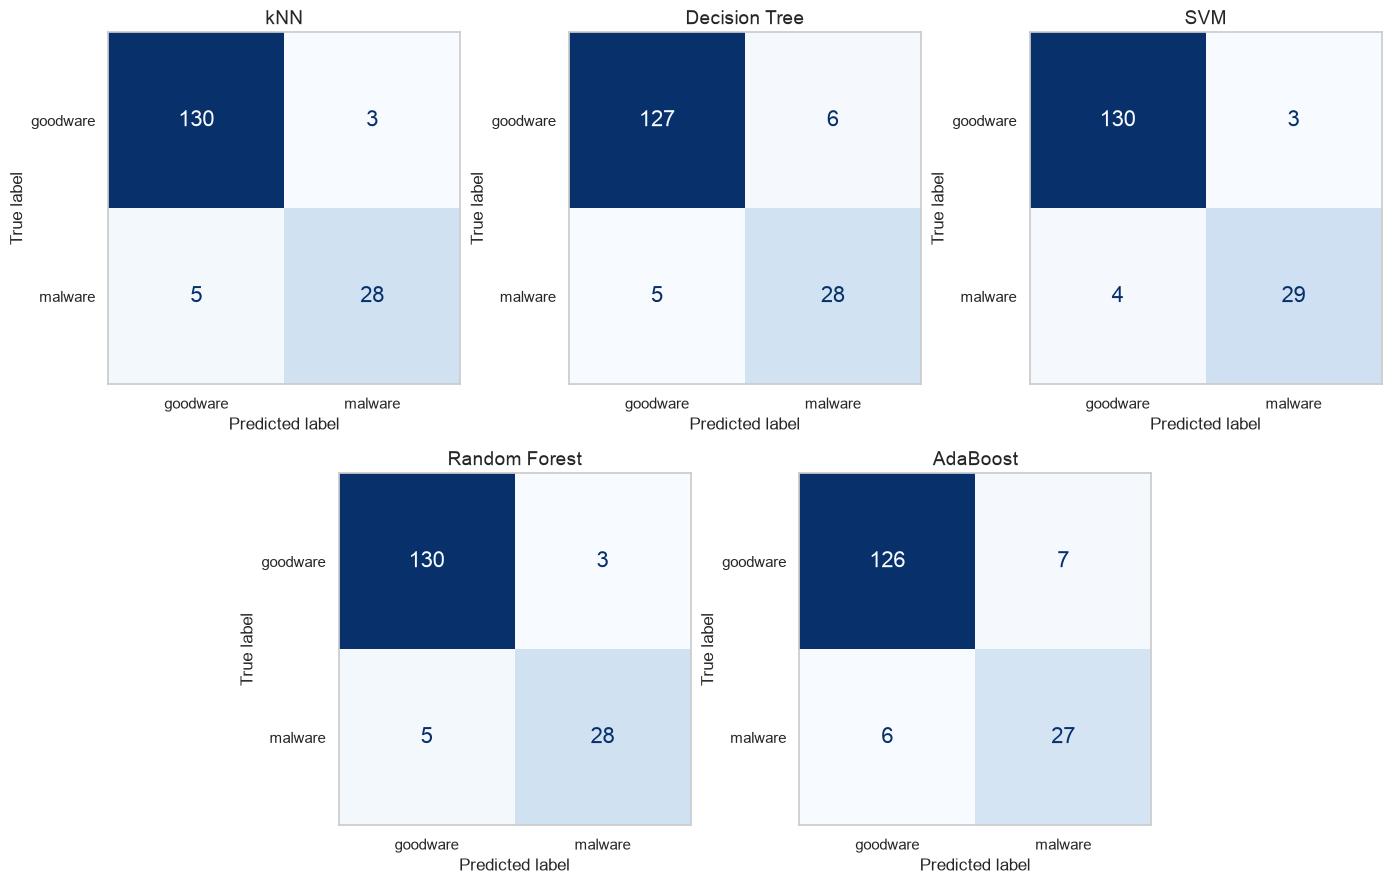

In [36]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 6)

positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]

for pos, (name, model) in zip(positions, tuned.items()):
    ax = fig.add_subplot(pos)
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['goodware', 'malware']).plot(
        ax=ax, colorbar=False, cmap='Blues', text_kw={'fontsize': 16})
    ax.set_title(name, fontsize=14)
    ax.grid(False)

plt.tight_layout()
plt.show()

SVM пропустив 4 з 33 шкідливих застосунків і помилково позначив 3 звичайних. Random Forest і kNN пропустили 5 і теж дали 3 хибних спрацювання. Дерево рішень пропустило 5 і дало 6 хибних спрацювань, а AdaBoost пропустив 6 і дав 7 хибних спрацювань.

<p align="center"><i><ins>[VII.c] Підсумкове порівняння</ins></i></p>

In [27]:
rows = []
for name, model in tuned.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    rows.append({**evaluate(model, name),
                 'CV F1': cv_scores.mean(), 'CV std': cv_scores.std(),
                 'F1 до тюнінгу (test)': baseline.loc[name, 'F1 (malware)']})

summary = pd.DataFrame(rows).set_index('Модель').round(3).sort_values('CV F1', ascending=False)
summary

,Accuracy,Precision,Recall,F1 (malware),F1-macro,CV F1,CV std,F1 до тюнінгу (test)
Модель,,,,,,,,
Random Forest,0.952,0.903,0.848,0.875,0.923,0.907,0.038,0.862
SVM,0.958,0.906,0.879,0.892,0.933,0.884,0.076,0.900
AdaBoost,0.922,0.794,0.818,0.806,0.878,0.868,0.038,0.824
kNN,0.952,0.903,0.848,0.875,0.923,0.852,0.036,0.862
Decision Tree,0.934,0.824,0.848,0.836,0.897,0.838,0.028,0.789


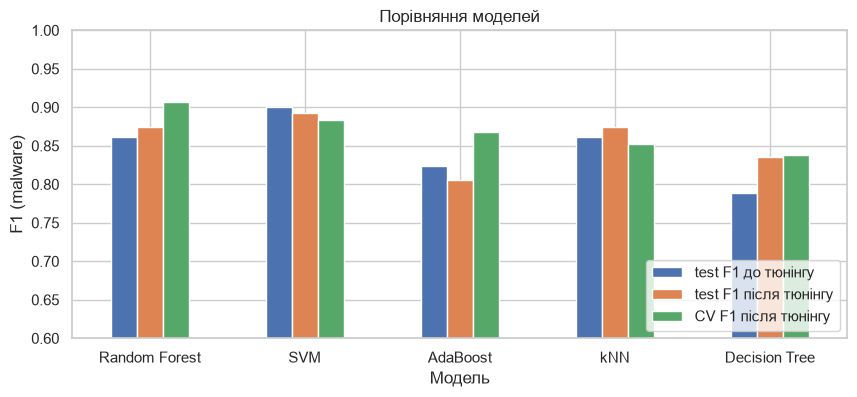

In [28]:
summary[['F1 до тюнінгу (test)', 'F1 (malware)', 'CV F1']].plot.bar(figsize=(10, 4), rot=0)
plt.ylim(0.6, 1); plt.ylabel('F1 (malware)')
plt.title('Порівняння моделей')
plt.legend(['test F1 до тюнінгу', 'test F1 після тюнінгу', 'CV F1 після тюнінгу'], loc='lower right')
plt.show()

Після підбору параметрів F1 на крос-валідації покращився у всіх моделей. На тесті ж у SVM і AdaBoost F1 трохи знизився, але це різниця всього в одну-дві помилки на маленькій вибірці. Наприклад, SVM до підбору параметрів не мав хибних спрацювань, але пропускав 6 шкідливих застосунків, а після має 3 хибних спрацювання і 4 пропуски. Тому при виборі моделі більше уваги приділено крос-валідації.

Для Random Forest також виведено найважливіші ознаки:

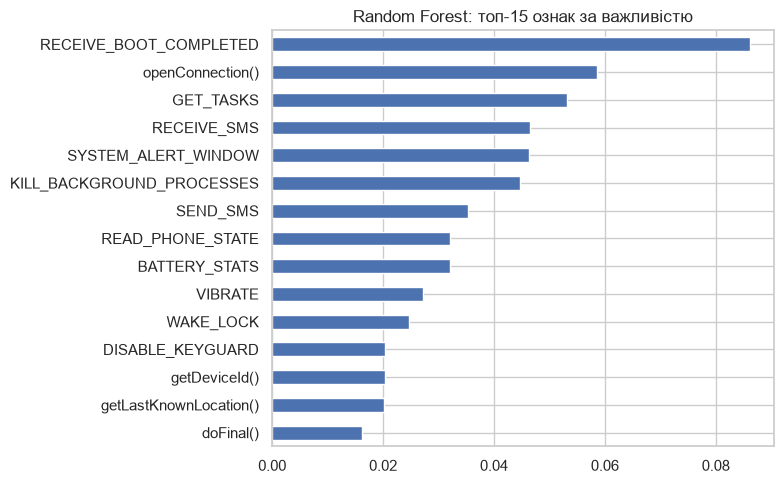

In [29]:
rf = tuned['Random Forest']
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False).head(15)
imp.rename(short).iloc[::-1].plot.barh(figsize=(8, 5))
plt.title('Random Forest: топ-15 ознак за важливістю')
plt.tight_layout()
plt.show()

Модель спирається на ті самі ознаки, що були помітні під час аналізу даних, такі як автозапуск, SMS, GET_TASKS, READ_PHONE_STATE, openConnection() і тд. також серед важливих є getDeviceId() і doFinal(), тобто отримання ідентифікатора пристрою і шифрування даних.

Наостанок перевірено, як вплинули б дублікати. Для цього Random Forest навчено на початкових даних без їх видалення:

In [30]:
Xf, yf = df_full[features], df_full[target]
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.25, stratify=yf, random_state=RANDOM_STATE)

train_rows = set(map(tuple, Xf_tr.values))
in_train = np.mean([tuple(r) in train_rows for r in Xf_te.values])
rf_full = RandomForestClassifier(random_state=RANDOM_STATE).fit(Xf_tr, yf_tr)

print(f'Тестових рядків, які дослівно є в train: {in_train * 100:.1f}%')
print(f'F1 (malware) Random Forest на даних з дублікатами: {f1_score(yf_te, rf_full.predict(Xf_te)):.3f}')

Тестових рядків, які дослівно є в train: 90.1%
F1 (malware) Random Forest на даних з дублікатами: 0.998


90% тестових рядків є і в навчальній вибірці, тому F1 виходить майже 1. Тобто з дублікатами модель здебільшого просто впізнає вже знайомі рядки, і результат виходить завищеним.

Але витік можна прибрати й інакше, не видаляючи дублікати. Для цього дані ділять так, щоб усі однакові рядки разом потрапляли або тільки в навчальну, або тільки в тестову частину:

In [31]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# однакові рядки отримують однаковий номер групи, і група не розділяється між train і test
groups = Xf.astype(str).agg(''.join, axis=1).factorize()[0]
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

scores = cross_validate(RandomForestClassifier(random_state=RANDOM_STATE), Xf, yf,
                        groups=groups, cv=sgkf, scoring={'f1': 'f1', 'f1_macro': 'f1_macro'})

print('Груп однакових рядків:', groups.max() + 1)
print(f"F1 (malware): {scores['test_f1'].mean():.3f}")
print(f"F1-macro:     {scores['test_f1_macro'].mean():.3f}")

Груп однакових рядків: 660
F1 (malware): 0.984
F1-macro:     0.963


У такому варіанті витоку теж немає, бо однакові рядки ніколи не потрапляють одночасно в навчальну і тестову частину. Але F1 виходить близько 0.98, тобто помітно вище, ніж на унікальних рядках. Різниця в тому, як рахуються помилки. Якщо прибрати дублікати, то кожен набір дозволів зустрічається в даних лише один раз, і помилка на ньому рахується як одна помилка. А якщо дублікати залишити, то, наприклад, програма, яка повторюється в даних 500 разів, і в тесті буде присутня 500 разів. Якщо модель визначає її правильно, то це одразу 500 правильних відповідей. Такі часті програми модель визначає добре, тому загальний результат виходить вищим. 

Тобто перший (варіант, шо юзався в лабі) варіант показує, як модель справляється з різними за змістом застосунками, а другий показує, як вона працювала б на реальних даних, де одні й ті самі шкідливі програми трапляються дуже часто. Обидва підходи норм, просто в основній частині роботи використано більш суворий варік.

З усіх моделей найкраще себе показав Random Forest. У нього найвищий F1 на крос-валідації (0.907), тобто в середньому він працює найкраще. На тесті трохи кращий SVM (0.892 проти 0.875), але це різниця всього в один знайдений шкідливий застосунок, а на крос-валідації SVM помітно гірший і має найбільший розкид результатів. На мою думку, Random Forest краще підходить для цих даних, бо шкідливі застосунки визначаються саме "комбінаціями" дозволів, а дерева якраз і будують такі правила. При цьому багато дерев разом перенавчаються менше, ніж одне дерево.

<h2>[VIII] Загальні висновки</h2>

В ході виконання лабораторної роботи було пройдено всі основні етапи розв'язання задачі класифікації на прикладі виявлення шкідливих Android-застосунків за їхніми дозволами та викликами API. Під час первинного аналізу було виявлено велику кількість дублікатів, які завищують результати, тому моделі навчались лише на унікальних записах. Дослідження даних показало, що класи відрізняються не однією ознакою, а набором підозрілих дозволів. Було навчено та порівняно kNN, дерево рішень, SVM, Random Forest і AdaBoost, підібрано їхні параметри за допомогою крос-валідації і з'ясовано, що для бінарних ознак масштабування не покращує результат. Найкращий результат показав Random Forest. Також стало зрозуміло, що при незбалансованих класах не варто орієнтуватись лише на accuracy, а результати моделей сильно залежать від якості самих даних.